## Kitabxanalar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data

In [2]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\companies.csv")
print(df.head())

  Company_name                                        Description  Ratings  \
0          TCS  IT Services & Consulting | 1 Lakh+ Employees |...      3.8   
1    Accenture  IT Services & Consulting | 1 Lakh+ Employees |...      4.0   
2    Cognizant  IT Services & Consulting | 1 Lakh+ Employees |...      3.9   
3        Wipro  IT Services & Consulting | 1 Lakh+ Employees |...      3.8   
4    Capgemini  IT Services & Consulting | 1 Lakh+ Employees |...      3.9   

                                    Highly_rated_for  \
0                    Job Security, Work Life Balance   
1  Company Culture, Skill Development / Learning,...   
2                       Skill Development / Learning   
3                                       Job Security   
4  Job Security, Work Life Balance, Skill Develop...   

                        Critically_rated_for Total_reviews Avg_salary  \
0  Promotions / Appraisal, Salary & Benefits         73.1k     856.9k   
1                                        NaN    

## Sual 1 (5/ )

Neçə fərqli şirkət bizim datasetdə iştirak edir?

In [3]:
print(df['Company_name'].nunique())

9355


## Sual 2 (5/ )

Şirkətlərin Rating-lərinin ortalamasını, medianını və standard yayınmasını tapın

In [4]:
print("Ortalama:", df['Ratings'].mean())
print("Median:", df['Ratings'].median())
print("Standart yayınma:", df['Ratings'].std())

Ortalama: 3.89471
Median: 3.9
Standart yayınma: 0.38589364764235734


## Sual 3 (5/ )

Ən yüksək reytinqə sahib 10 şirkəti tapın və bu şirkətləri vizuallaşdırın

                                        Company_name  Ratings
8749                                     Teqtous Inc      5.0
4340                               Matrimonialsindia      5.0
1400                             Lavender Technology      5.0
4916                  Deejos Engineers & Contractors      5.0
1759                                       InternEzy      5.0
3388  Dr.SNS Rajalakshmi College Of Arts and Science      5.0
9924                                        Salaryfy      5.0
8750                       Jayasree Techno Solutions      5.0
2137                       Royal Migration Solutions      5.0
7691                                      IBC Techno      5.0


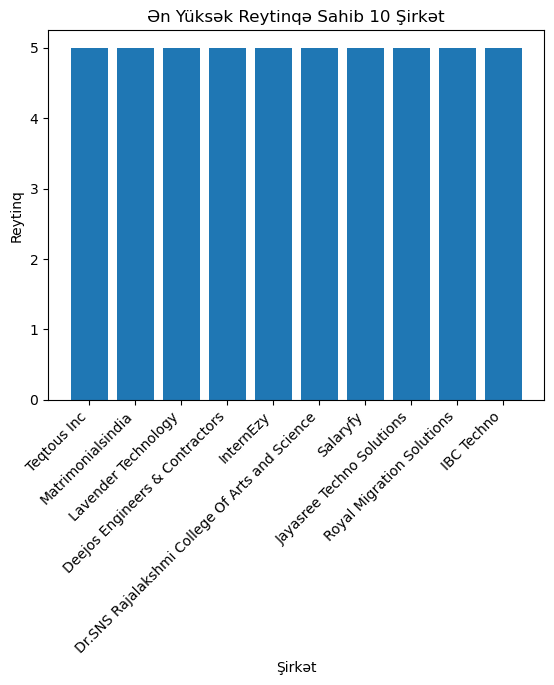

In [14]:
top10 = df.sort_values(by='Ratings', ascending=False).head(10)
print(top10[['Company_name', 'Ratings']])
plt.bar(top10['Company_name'], top10['Ratings'])
plt.xticks(rotation=45, ha='right')  
plt.title("Ən Yüksək Reytinqə Sahib 10 Şirkət")
plt.xlabel("Şirkət")
plt.ylabel("Reytinq")
plt.show()

## Sual 4 (20/ )

Datanın bəzi sütunları rəqəm ola biləcəyi halda object kimi görünür. Çünki içərisində fərqli (məs. k, --) dəyərlər mövcuddur. Biz bunlardan qurtularaq həmin sütunları rəqəmə çevirməliyik ki, hesablamalarımızı apara bilək. Bunun üçün aşağıdakı addımları izləyəcək kodları yazın:


Elə funksiyalar qurun ki, rəqəmə çevrilə biləcək sütunlarda:
- Xanadakı "k" hərfini silsin (**tips:** .replace())
- Xananı "--" işarəsini 0 ilə əvəzləsin
- Həmin xananı float tipinə çevirsin (**tips:** .astype())
- Həmin xananı 1000-ə vursun

Bu funksiyaları sıra ilə aşağıdakı sütunlara tətbiq edərək sütunları rəqəm halına gətirin:
 - Total_reviews
 - Avg_salary
 - Interviews_taken
 - Total_jobs_available
 - Total_benefits

In [15]:
def clean_numeric_column(col):
    col = col.replace("k", "", regex=True)   
    col = col.replace("--", "0", regex=True) 
    col = col.astype(float)                  
    col = col * 1000                         
    return col
numeric_cols = ['Total_reviews', 'Avg_salary', 'Interviews_taken', 'Total_jobs_available', 'Total_benefits']
for col in numeric_cols:
    df[col] = clean_numeric_column(df[col])

print(df[numeric_cols].head())

   Total_reviews  Avg_salary  Interviews_taken  Total_jobs_available  \
0        73100.0    856900.0            6100.0              847000.0   
1        46400.0    584600.0            4300.0                9900.0   
2        41700.0    561500.0            3600.0              460000.0   
3        39200.0    427400.0            3700.0              405000.0   
4        34000.0    414400.0            2800.0              719000.0   

   Total_benefits  
0         11500.0  
1          7100.0  
2          5800.0  
3          5000.0  
4          4000.0  


## Sual 5 (10/ )

Ən yüksək ortalama maaş verən şirkətlər hansılardır? (Top 10)

In [16]:
top_salary = df.sort_values(by='Avg_salary', ascending=False).head(10)
print(top_salary[['Company_name', 'Avg_salary']])

              Company_name  Avg_salary
3981    Savex Technologies    999000.0
2771                 Ricoh    999000.0
3443  MARK EXHAUST SYSTEMS    999000.0
2881             GSH Group    998000.0
5027  Umedica Laboratories    998000.0
4245        Rehau Polymers    998000.0
1918                   NLC    997000.0
3976          Vasta Global    997000.0
4720         Liugong India    997000.0
4102             KLJ GROUP    997000.0


## Sual 6 (10/ )

Ən çox qiymətləndirmə sayına sahib şirkətlərin ortalama maaşları nə qədərdir? (Total_reviews və Avg_salary sütunları)

In [17]:
top_reviews = df.sort_values(by='Total_reviews', ascending=False).head(10)
print(top_reviews[['Company_name', 'Total_reviews', 'Avg_salary']])
average_salary_top_reviews = top_reviews['Avg_salary'].mean()
print("\nBu şirkətlərin ortalama maaşı:", round(average_salary_top_reviews, 2))

                          Company_name  Total_reviews  Avg_salary
692                             Aircel       999000.0      1800.0
693                          Cinépolis       999000.0      2800.0
694                                IFB       997000.0      4500.0
695               Unichem Laboratories       997000.0      4800.0
696                          Synchrony       995000.0      5000.0
697  Iffco Tokio General Insurance Co.       994000.0      3900.0
698                    Indoco Remedies       993000.0      5100.0
699                        CorroHealth       991000.0      4300.0
701       Newgen Software Technologies       988000.0     10100.0
700                            Tanishq       988000.0      2400.0

Bu şirkətlərin ortalama maaşı: 4470.0


## Sual 7 (10/ )

Ortalama vakansiya sayından daha yüksək vakansiyaya sahib neçə fərqli şirkət var?

In [20]:
avg_jobs = df['Total_jobs_available'].mean()
print("Ortalama vakansiya sayı:", round(avg_jobs))
above_avg_jobs = df[df['Total_jobs_available'] > avg_jobs]
num_companies = above_avg_jobs['Company_name'].nunique()
print("Ortalama vakansiya sayından daha yüksək vakansiyaya sahib fərqli şirkət sayı:", num_companies)

Ortalama vakansiya sayı: 17314
Ortalama vakansiya sayından daha yüksək vakansiyaya sahib fərqli şirkət sayı: 1931


## Sual 8 (10/ )

Şirkətlərin arasından hansıları işçilər və ya namizədlər tərəfindən daha çox güvənilirlər (**tips:** Highly_rated_for sütununda "Job Security" olan sətrlər saxlanmalıdır. **tips 2:** .contains())

In [23]:
trusted_companies = df[df['Highly_rated_for'].str.contains("Job Security", na=False)]
print(trusted_companies[['Company_name', 'Highly_rated_for']])

                   Company_name  \
0                           TCS   
1                     Accenture   
3                         Wipro   
4                     Capgemini   
5                     HDFC Bank   
...                         ...   
9990  Terminal Technologies (i)   
9991                Simon India   
9992                   Volvo IT   
9994  MediaTek India Technology   
9999                  Beroe Inc   

                                       Highly_rated_for  
0                       Job Security, Work Life Balance  
1     Company Culture, Skill Development / Learning,...  
3                                          Job Security  
4     Job Security, Work Life Balance, Skill Develop...  
5            Job Security, Skill Development / Learning  
...                                                 ...  
9990  Skill Development / Learning, Job Security, Wo...  
9991  Job Security, Skill Development / Learning, Pr...  
9992   Job Security, Work Life Balance, Company Culture  

## Sual 9 (15/ )

**Highly_rated_for** sütununda Benefits seçilən şirkətlərin ortalama nə qədər benefit verdiyini hesablayın. Daha sonra ən çox benefit verən 10 şirkəti vizuallaşdırın.

Benefits seçilən şirkətlərin ortalama benefit sayı: 40167


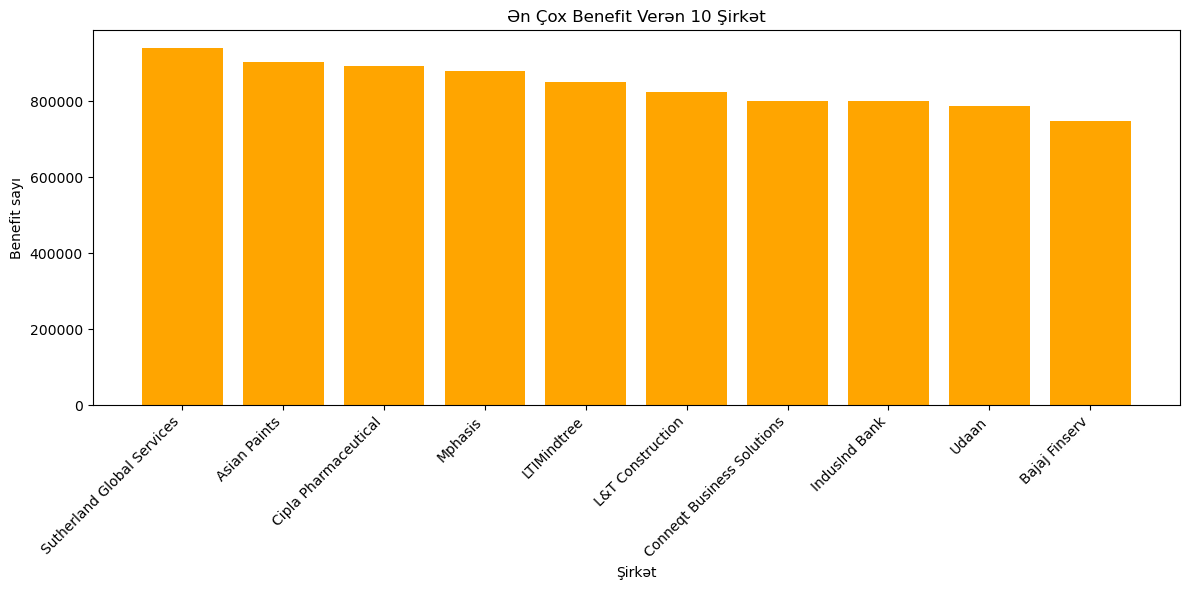

In [24]:
benefit_companies = df[df['Highly_rated_for'].str.contains("Benefits", na=False)]
avg_benefit = benefit_companies['Total_benefits'].mean()
print("Benefits seçilən şirkətlərin ortalama benefit sayı:", round(avg_benefit))
top10_benefit = benefit_companies.sort_values(by='Total_benefits', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10_benefit['Company_name'], top10_benefit['Total_benefits'], color='orange')
plt.xticks(rotation=45, ha='right')
plt.title("Ən Çox Benefit Verən 10 Şirkət")
plt.xlabel("Şirkət")
plt.ylabel("Benefit sayı")
plt.tight_layout()
plt.show()

## Sual 10 (10/ )

Bank sektorunda olan şirkətlərin median maaşları nə qədərdir?

In [25]:
bank_companies = df[df['Description'].str.contains("Bank", na=False)]
median_salary_bank = bank_companies['Avg_salary'].median()
print("Bank sektorunda olan şirkətlərin median maaşı:", round(median_salary_bank,2))

Bank sektorunda olan şirkətlərin median maaşı: 20700.0


## Bonus (10/ )

Hazırladığınız vizuallardan bir ədəd dashboard qurun

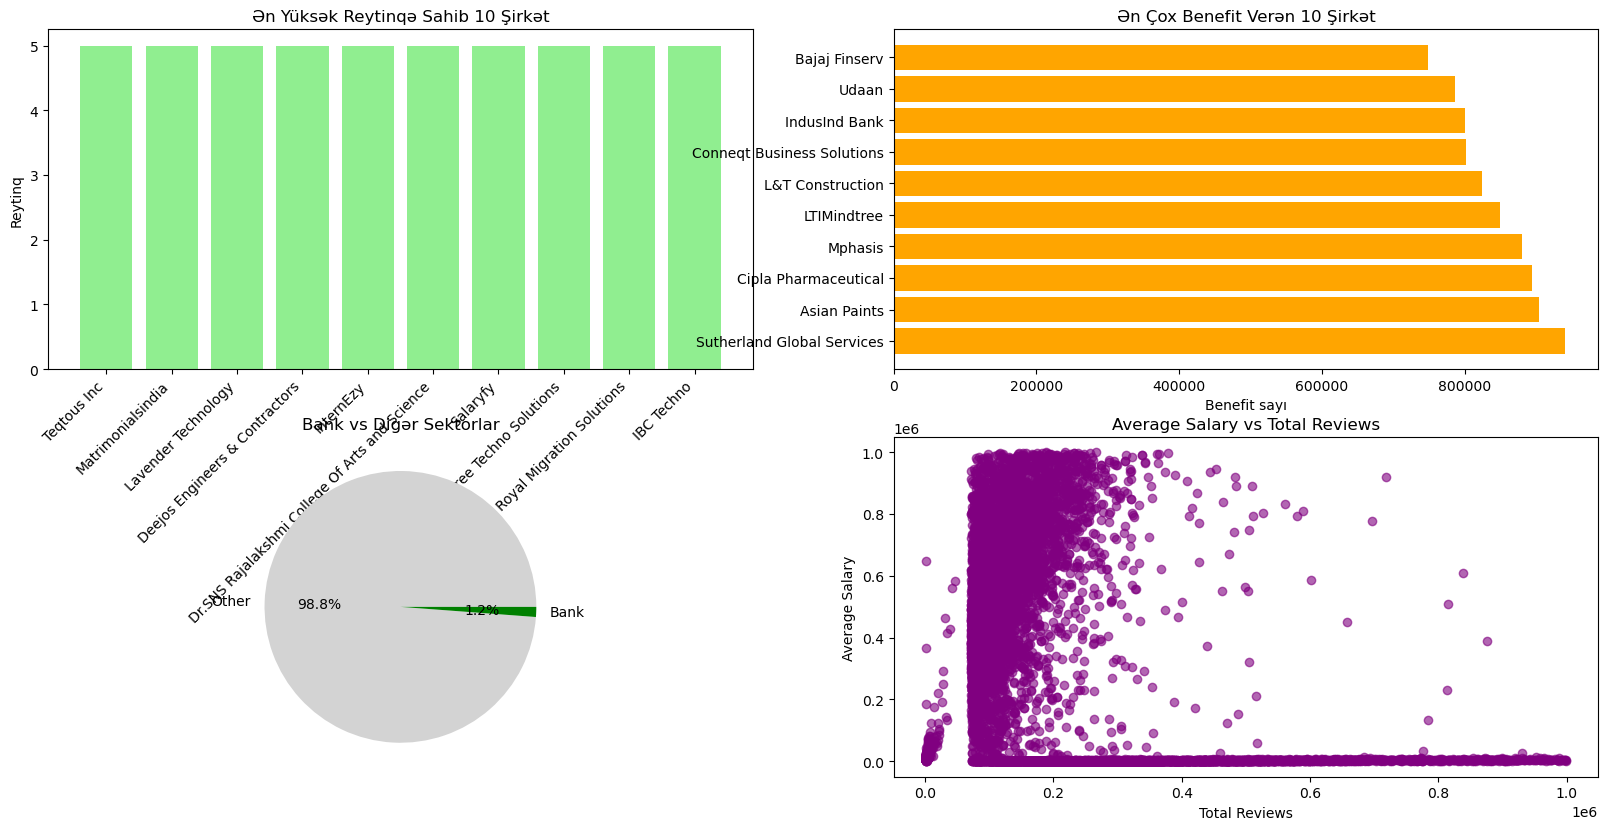

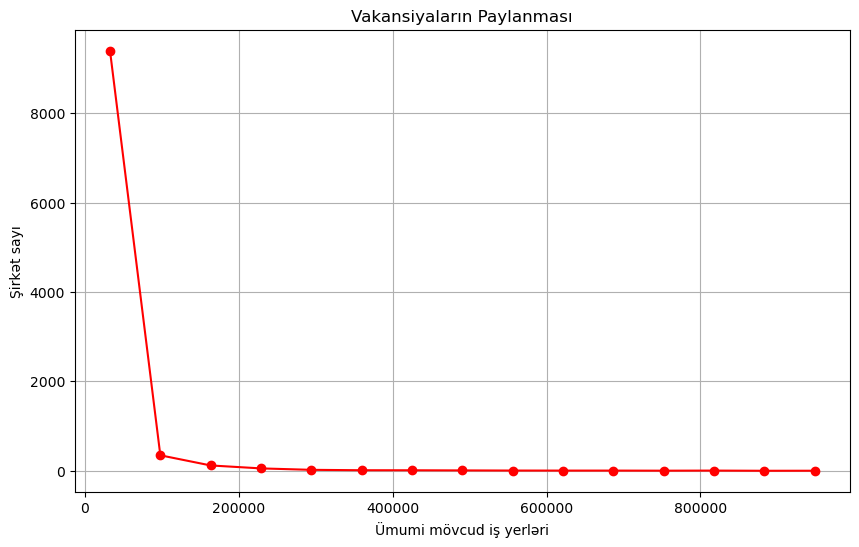

In [30]:
plt.figure(figsize=(20,15))

# Bar chart: Ən Yüksək Reytinqə Sahib 10 Şirkət
plt.subplot(3,2,1)
plt.bar(top10['Company_name'], top10['Ratings'], color='lightgreen')
plt.xticks(rotation=45, ha='right')
plt.title("Ən Yüksək Reytinqə Sahib 10 Şirkət")
plt.ylabel("Reytinq")

# Horizontal bar chart: Ən Çox Benefit Verən 10 Şirkət
plt.subplot(3,2,2)
plt.barh(top10_benefit['Company_name'], top10_benefit['Total_benefits'], color='orange')
plt.title("Ən Çox Benefit Verən 10 Şirkət")
plt.xlabel("Benefit sayı")

# Pie chart: Bank vs Digər sektorlar
df['Sector'] = np.where(df['Description'].str.contains('Bank', na=False), 'Bank', 'Other')
sector_counts = df['Sector'].value_counts()
plt.subplot(3,2,3)
plt.pie(sector_counts, labels=sector_counts.index, autopct='%1.1f%%', colors=['lightgrey','green'])
plt.title("Bank vs Digər Sektorlar")

#  Scatter chart: Avg_salary vs Total_reviews
plt.subplot(3,2,4)
plt.scatter(df['Total_reviews'], df['Avg_salary'], color='purple', alpha=0.6)
plt.title("Average Salary vs Total Reviews")
plt.xlabel("Total Reviews")
plt.ylabel("Average Salary")

# Line chart: Vakansiyaların Paylanması
counts, bins = np.histogram(df['Total_jobs_available'], bins=15)
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.figure(figsize=(10,6))
plt.plot(bin_centers, counts, color='red', marker='o', linestyle='-')
plt.title("Vakansiyaların Paylanması")
plt.xlabel("Ümumi mövcud iş yerləri")
plt.ylabel("Şirkət sayı")
plt.grid(True)
plt.show()

# **UĞURLAR!**